### 1. Business Understanding
**Tujuan Proyek:** Memetakan dan memantau secara proaktif fluktuasi kualitas udara di wilayah Kecamatan Kwanyar menggunakan data penginderaan jauh satelit Sentinel-5P selama kurun waktu satu tahun terakhir.

**Manfaat Proyek:**
1. **Sistem Peringatan Dini Kesehatan:** Memberikan peringatan berbasis data bagi masyarakat dan kelompok rentan saat angka polutan harian melonjak agar membatasi aktivitas outdoor.
2. **Evaluasi Tata Ruang & Kebijakan:** Menjadi landasan objektif bagi instansi terkait maupun pengelola kawasan untuk mengevaluasi kepadatan lalu lintas dan efektivitas ruang terbuka hijau.
3. **Transparansi Informasi Publik:** Menerjemahkan matriks data satelit yang rumit menjadi grafik time series visual di portal web statis agar ancaman "polusi tak kasatmata" mudah dipahami oleh warga sipil.

### 2. Data Understanding
Dataset ini berisi rekaman harian konsentrasi gas polutan yang diekstrak menggunakan agregasi spasial (Polygon GeoJSON) wilayah Kwanyar.

**Deskripsi Fitur Polutan:**
* **CO (Karbon Monoksida):** Silent killer tak berbau dari pembakaran tidak sempurna, utamanya disumbang oleh asap knalpot kendaraan atau pembakaran sampah terbuka.
* **$NO_2$ (Nitrogen Dioksida):** Gas reaktif pemicu radang pernapasan, berasal dari emisi mesin bahan bakar fosil (terutama diesel) dan aktivitas industri.
* **$O_3$ (Ozon Permukaan):** Polutan sekunder berbahaya yang terbentuk dari reaksi kimia gas buang kendaraan di bawah terik matahari.
* **$SO_2$ (Sulfur Dioksida):** Gas berbau menyengat penyebab hujan asam, umumnya dari pembakaran batu bara atau emisi bahan bakar kapal laut di area pesisir.

**Catatan Eksplorasi Data (Anomali):** Dalam data satelit optik, terdapat kondisi wajar yang perlu diperhatikan:
1. **Missing Values (NaN):** Terjadi ketika wilayah tertutup awan mendung/hujan, sehingga sensor satelit tidak dapat menembus permukaan bumi.
2. **Outliers (Pencilan):** Lonjakan nilai ekstrem pada hari tertentu yang bisa merekam insiden nyata (kebakaran lahan) atau sekadar noise instrumen.

### 3. Persiapan Lingkungan & Koneksi Server
Langkah teknis dimulai dengan memasang pustaka openeo dan mengautentikasi sistem lokal ke peladen Copernicus Data Space Ecosystem (CDSE). Koordinat Kwanyar didefinisikan menggunakan GeoJSON.

In [2]:
!pip install openeo pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 357.0/357.0 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 6.2 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


In [3]:
import openeo
import json
import pandas as pd
from functools import reduce
import matplotlib.pyplot as plt

print("Menghubungkan ke CDSE Copernicus...")
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

# Koordinat area Kwanyar
aoi = {
  "type": "Polygon",
  "coordinates": [
    [
      [112.8427406, -7.1721912],
      [112.8427406, -7.140546],
      [112.8864026, -7.140546],
      [112.8864026, -7.1721912],
      [112.8427406, -7.1721912]
    ]
  ]
}

# Batasan kotak (Bounding Box) Kwanyar
spatial_ext = {"west": 112.821, "south": -7.185293, "east": 112.920163, "north": -7.107936}

Menghubungkan ke CDSE Copernicus...


Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=QMWW-UUXX 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.


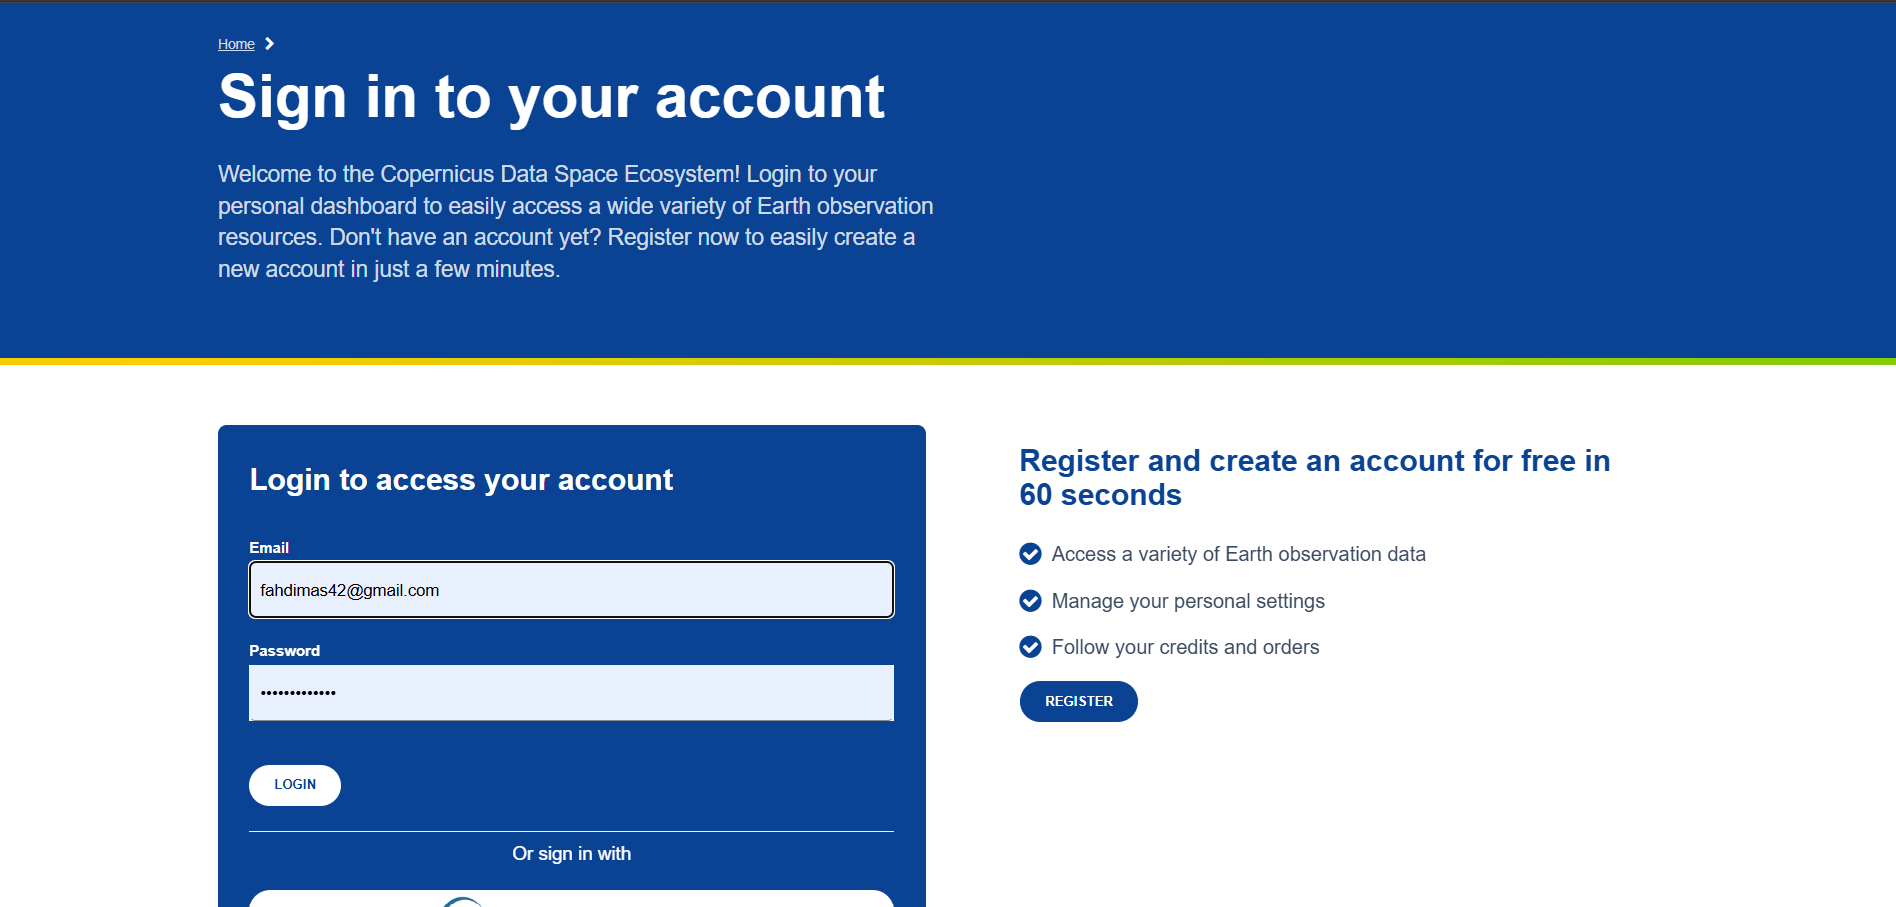

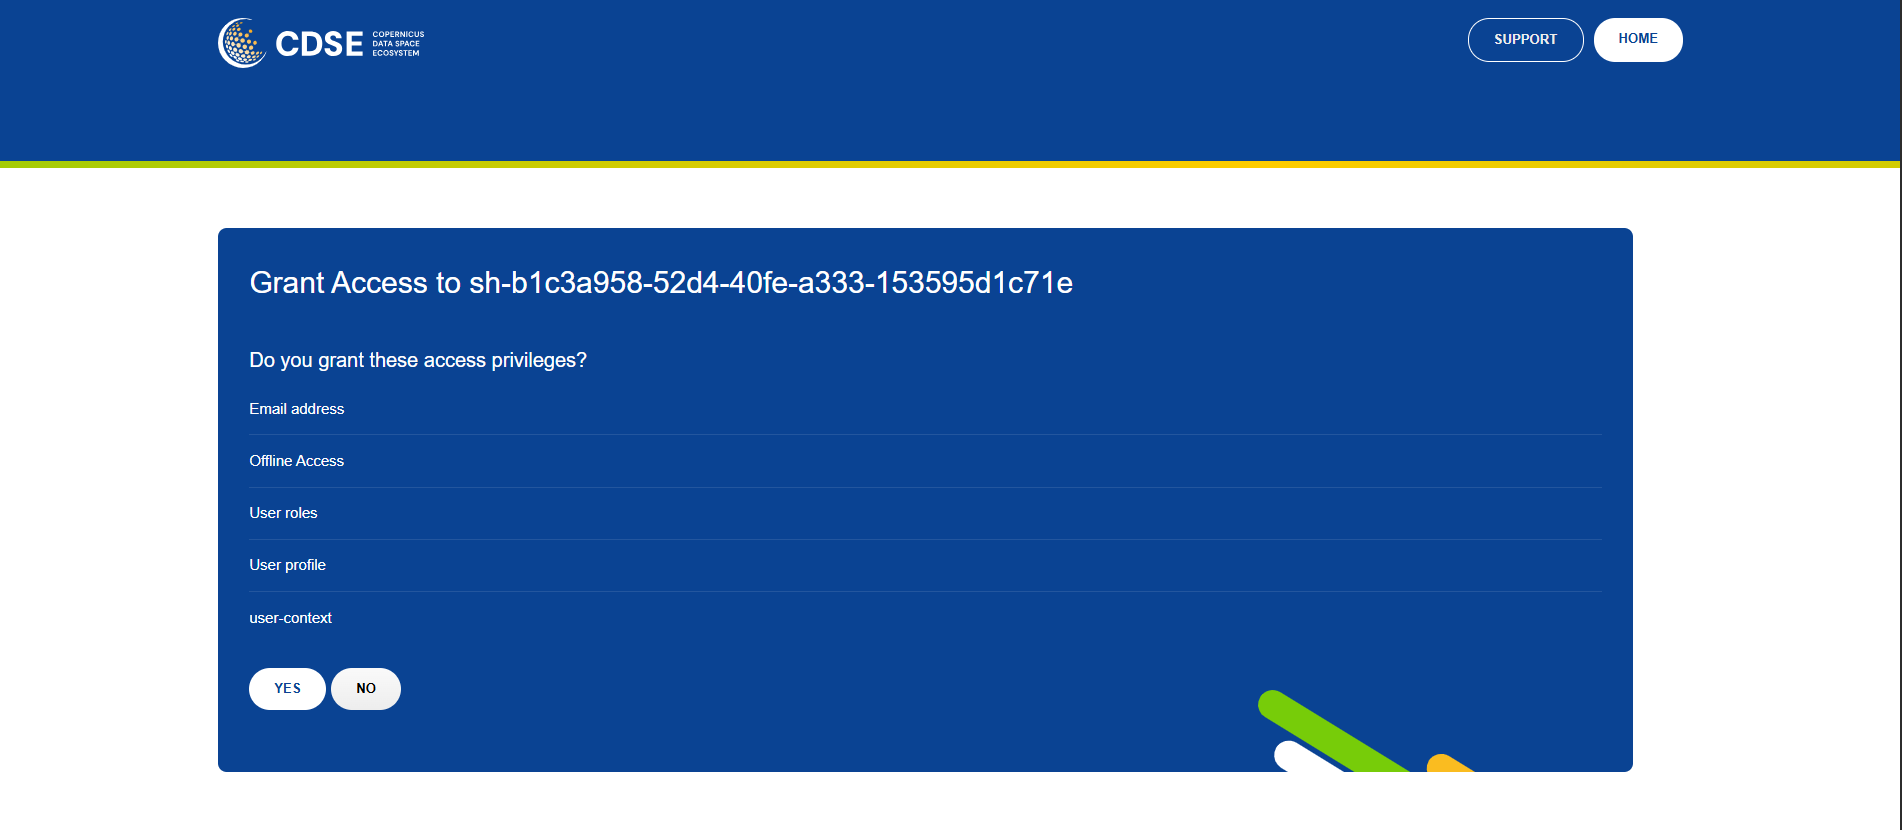

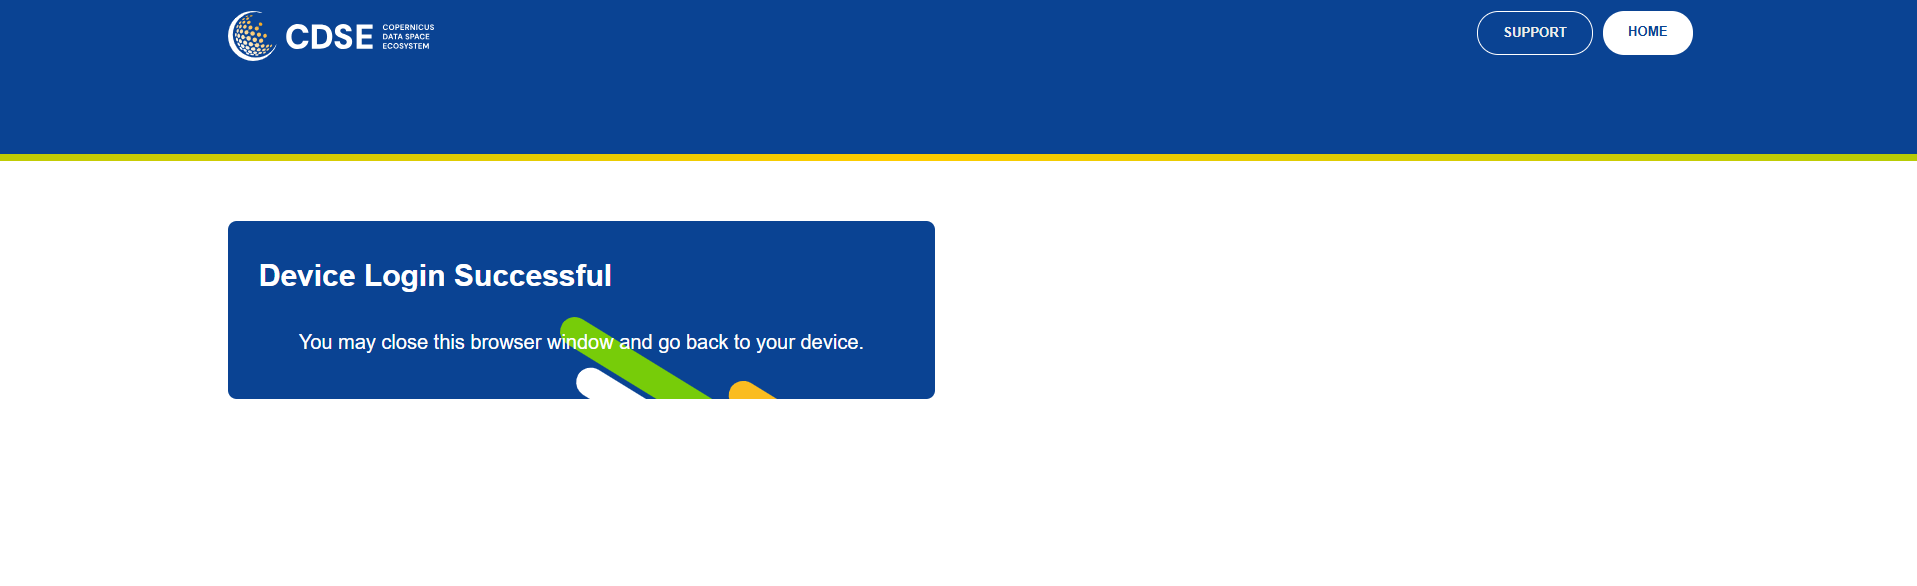

### 4. Pengambilan Data Satelit

#### 4.1 Ekstraksi Nitrogen Dioksida ($NO_2$)
Sel ini bertugas memanggil parameter gas $NO_2$ berdasarkan koordinat yang telah ditentukan.

In [5]:
gas_target = "NO2"
cube = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-31", "2026-08-31"],
    spatial_extent=spatial_ext,
    bands=[gas_target]
)
cube_aoi = cube.aggregate_temporal_period(reducer="mean", period="day").aggregate_spatial(reducer="mean", geometries=aoi)

nc_filename = f"{gas_target}_Kwanyar.nc"
job = cube_aoi.execute_batch(title=f"{gas_target}_Kwanyar")
job.download_result(target=nc_filename)

with open(nc_filename, "r") as f:
    data_json = json.load(f)

records = [{'date': date_str, gas_target: (val[0][0] if val and val[0] else None)} for date_str, val in data_json.items()]
df_no2 = pd.DataFrame(records)
df_no2['date'] = pd.to_datetime(df_no2['date']).dt.date

0:00:00 Job 'j-2609101642374cd5b39dc78d1c94b689': send 'start'
0:00:04 Job 'j-2609101642374cd5b39dc78d1c94b689': queued (progress 0%)
0:00:09 Job 'j-2609101642374cd5b39dc78d1c94b689': queued (progress 0%)
0:00:15 Job 'j-2609101642374cd5b39dc78d1c94b689': queued (progress 0%)
0:00:23 Job 'j-2609101642374cd5b39dc78d1c94b689': queued (progress 0%)
0:00:33 Job 'j-2609101642374cd5b39dc78d1c94b689': queued (progress 0%)
0:00:46 Job 'j-2609101642374cd5b39dc78d1c94b689': queued (progress 0%)
0:01:01 Job 'j-2609101642374cd5b39dc78d1c94b689': queued (progress 0%)
0:01:21 Job 'j-2609101642374cd5b39dc78d1c94b689': queued (progress 0%)
0:01:45 Job 'j-2609101642374cd5b39dc78d1c94b689': queued (progress 0%)
0:02:15 Job 'j-2609101642374cd5b39dc78d1c94b689': queued (progress 0%)
0:02:52 Job 'j-2609101642374cd5b39dc78d1c94b689': running (progress N/A)
0:03:39 Job 'j-2609101642374cd5b39dc78d1c94b689': running (progress N/A)
0:04:38 Job 'j-2609101642374cd5b39dc78d1c94b689': running (progress N/A)
0:05:38 

#### 4.2 Ekstraksi Karbon Monoksida (CO)
Selanjutnya, kita menarik data Karbon Monoksida (CO) dengan rentang waktu yang sama.

In [6]:
gas_target = "CO"
cube = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-31", "2026-08-31"],
    spatial_extent=spatial_ext,
    bands=[gas_target]
)
cube_aoi = cube.aggregate_temporal_period(reducer="mean", period="day").aggregate_spatial(reducer="mean", geometries=aoi)

nc_filename = f"{gas_target}_Kwanyar.nc"
job = cube_aoi.execute_batch(title=f"{gas_target}_Kwanyar")
job.download_result(target=nc_filename)

with open(nc_filename, "r") as f:
    data_json = json.load(f)

records = [{'date': date_str, gas_target: (val[0][0] if val and val[0] else None)} for date_str, val in data_json.items()]
df_co = pd.DataFrame(records)
df_co['date'] = pd.to_datetime(df_co['date']).dt.date

0:00:00 Job 'j-260910164822434ab09fe8b584fb9858': send 'start'
0:00:04 Job 'j-260910164822434ab09fe8b584fb9858': created (progress 0%)
0:00:09 Job 'j-260910164822434ab09fe8b584fb9858': queued (progress 0%)
0:00:16 Job 'j-260910164822434ab09fe8b584fb9858': queued (progress 0%)
0:00:24 Job 'j-260910164822434ab09fe8b584fb9858': queued (progress 0%)
0:00:34 Job 'j-260910164822434ab09fe8b584fb9858': queued (progress 0%)
0:00:47 Job 'j-260910164822434ab09fe8b584fb9858': queued (progress 0%)
0:01:02 Job 'j-260910164822434ab09fe8b584fb9858': running (progress N/A)
0:01:21 Job 'j-260910164822434ab09fe8b584fb9858': running (progress N/A)
0:01:45 Job 'j-260910164822434ab09fe8b584fb9858': running (progress N/A)
0:02:16 Job 'j-260910164822434ab09fe8b584fb9858': running (progress N/A)
0:02:53 Job 'j-260910164822434ab09fe8b584fb9858': running (progress N/A)
0:03:40 Job 'j-260910164822434ab09fe8b584fb9858': running (progress N/A)
0:04:39 Job 'j-260910164822434ab09fe8b584fb9858': finished (progress 100

#### 4.3 Ekstraksi Ozon Permukaan ($O_3$)
Data $O_3$ ditarik untuk melihat seberapa besar paparan ozon permukaan akibat reaksi polutan.

In [7]:
gas_target = "O3"
cube = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-31", "2026-08-31"],
    spatial_extent=spatial_ext,
    bands=[gas_target]
)
cube_aoi = cube.aggregate_temporal_period(reducer="mean", period="day").aggregate_spatial(reducer="mean", geometries=aoi)

nc_filename = f"{gas_target}_Kwanyar.nc"
job = cube_aoi.execute_batch(title=f"{gas_target}_Kwanyar")
job.download_result(target=nc_filename)

with open(nc_filename, "r") as f:
    data_json = json.load(f)

records = [{'date': date_str, gas_target: (val[0][0] if val and val[0] else None)} for date_str, val in data_json.items()]
df_o3 = pd.DataFrame(records)
df_o3['date'] = pd.to_datetime(df_o3['date']).dt.date

0:00:00 Job 'j-2609101653084c56aeeeaa6939623018': send 'start'
0:00:04 Job 'j-2609101653084c56aeeeaa6939623018': created (progress 0%)
0:00:09 Job 'j-2609101653084c56aeeeaa6939623018': queued (progress 0%)
0:00:15 Job 'j-2609101653084c56aeeeaa6939623018': queued (progress 0%)
0:00:23 Job 'j-2609101653084c56aeeeaa6939623018': queued (progress 0%)
0:00:34 Job 'j-2609101653084c56aeeeaa6939623018': queued (progress 0%)
0:00:46 Job 'j-2609101653084c56aeeeaa6939623018': queued (progress 0%)
0:01:02 Job 'j-2609101653084c56aeeeaa6939623018': queued (progress 0%)
0:01:21 Job 'j-2609101653084c56aeeeaa6939623018': running (progress N/A)
0:01:45 Job 'j-2609101653084c56aeeeaa6939623018': running (progress N/A)
0:02:15 Job 'j-2609101653084c56aeeeaa6939623018': running (progress N/A)
0:02:53 Job 'j-2609101653084c56aeeeaa6939623018': running (progress N/A)
0:03:40 Job 'j-2609101653084c56aeeeaa6939623018': finished (progress 100%)


#### 4.4 Ekstraksi Sulfur Dioksida ($SO_2$)
Terakhir, mengambil data emisi Sulfur Dioksida ($SO_2$).

In [8]:
gas_target = "SO2"
cube = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-31", "2026-08-31"],
    spatial_extent=spatial_ext,
    bands=[gas_target]
)
cube_aoi = cube.aggregate_temporal_period(reducer="mean", period="day").aggregate_spatial(reducer="mean", geometries=aoi)

nc_filename = f"{gas_target}_Kwanyar.nc"
job = cube_aoi.execute_batch(title=f"{gas_target}_Kwanyar")
job.download_result(target=nc_filename)

with open(nc_filename, "r") as f:
    data_json = json.load(f)

records = [{'date': date_str, gas_target: (val[0][0] if val and val[0] else None)} for date_str, val in data_json.items()]
df_so2 = pd.DataFrame(records)
df_so2['date'] = pd.to_datetime(df_so2['date']).dt.date

0:00:00 Job 'j-2609101656584e118a59fbb9a92ad364': send 'start'
0:00:04 Job 'j-2609101656584e118a59fbb9a92ad364': queued (progress 0%)
0:00:10 Job 'j-2609101656584e118a59fbb9a92ad364': queued (progress 0%)
0:00:16 Job 'j-2609101656584e118a59fbb9a92ad364': queued (progress 0%)
0:00:24 Job 'j-2609101656584e118a59fbb9a92ad364': queued (progress 0%)
0:00:34 Job 'j-2609101656584e118a59fbb9a92ad364': queued (progress 0%)
0:00:47 Job 'j-2609101656584e118a59fbb9a92ad364': queued (progress 0%)
0:01:02 Job 'j-2609101656584e118a59fbb9a92ad364': queued (progress 0%)
0:01:22 Job 'j-2609101656584e118a59fbb9a92ad364': running (progress N/A)
0:01:46 Job 'j-2609101656584e118a59fbb9a92ad364': running (progress N/A)
0:02:16 Job 'j-2609101656584e118a59fbb9a92ad364': running (progress N/A)
0:02:54 Job 'j-2609101656584e118a59fbb9a92ad364': running (progress N/A)
0:03:40 Job 'j-2609101656584e118a59fbb9a92ad364': running (progress N/A)
0:04:39 Job 'j-2609101656584e118a59fbb9a92ad364': finished (progress 100%)


#### 4.5 Integrasi Master Dataset
Proses penggabungan file dari setiap fitur polutan menjadi satu dataframe utuh untuk mempermudah pemeriksaan struktur dan analisis data lanjutan.

In [9]:
dfs = [df_no2, df_co, df_o3, df_so2]

for df in dfs:
    df['date'] = pd.to_datetime(df['date'])

df_merged = reduce(lambda left, right: pd.merge(left, right, on='date', how='outer'), dfs)
df_merged = df_merged.sort_values('date').reset_index(drop=True)
df_merged.to_csv("KualitasUdara_Kwanyar.csv", index=False)

### 5. Pengecekan Missing Value
Pengecekan missing values ini dilakukan untuk mengetahui persentase data yang kosong atau hilang.

In [10]:
df = pd.read_csv("KualitasUdara_Kwanyar.csv")
df['date'] = pd.to_datetime(df['date'])

missing_count = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100
df_missing = pd.DataFrame({'Jumlah Missing Value': missing_count, 'Persentase (%)': missing_percentage})

print("--- LAPORAN PENGECEKAN MISSING VALUE ---")
print(df_missing)

--- LAPORAN PENGECEKAN MISSING VALUE ---
      Jumlah Missing Value  Persentase (%)
date                     0        0.000000
NO2                    173       47.267760
CO                     205       56.010929
O3                       5        1.366120
SO2                    146       39.890710


### 6. Deteksi Data Aneh (Outliers) & Visualisasi
Kadar polusi udara bisa saja memiliki anomali atau outlier akibat cuaca ekstrem atau lonjakan emisi tiba-tiba. Deteksi anomali ini menggunakan metode Interquartile Range (IQR) dengan batas bawah (lower bound) dan batas atas (upper bound). Visualisasi di bawah ini menampilkan fluktuasi time series dengan titik merah sebagai representasi outlier.

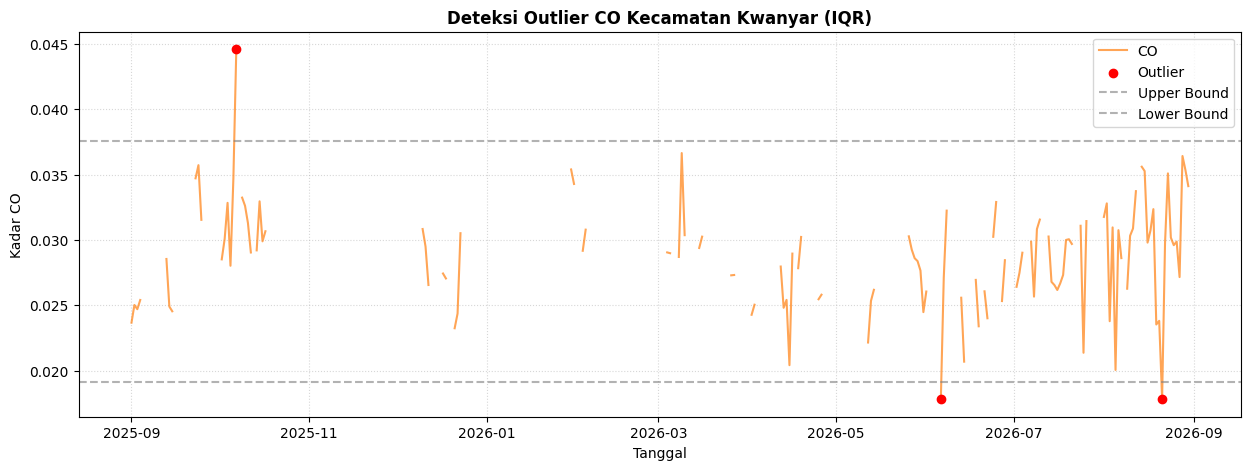

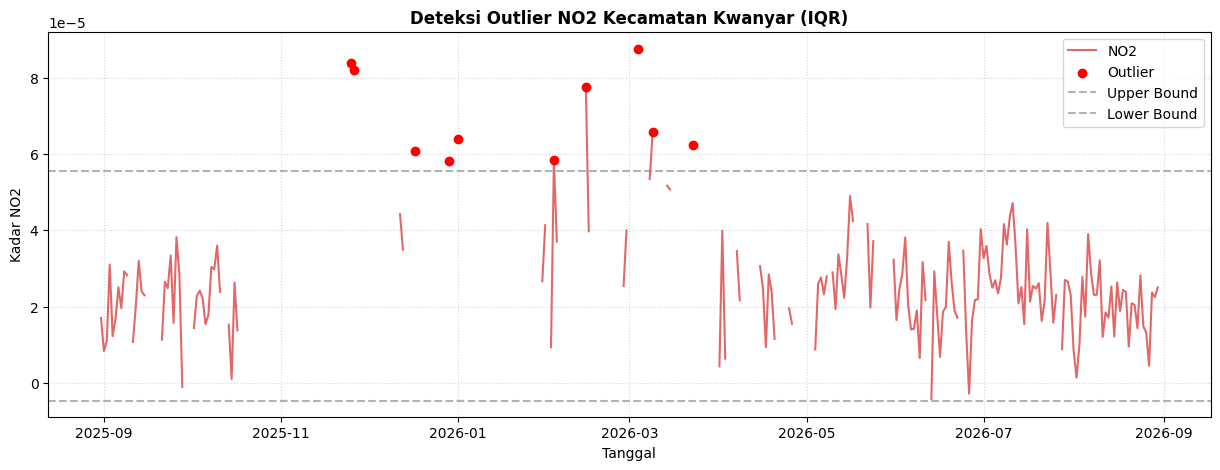

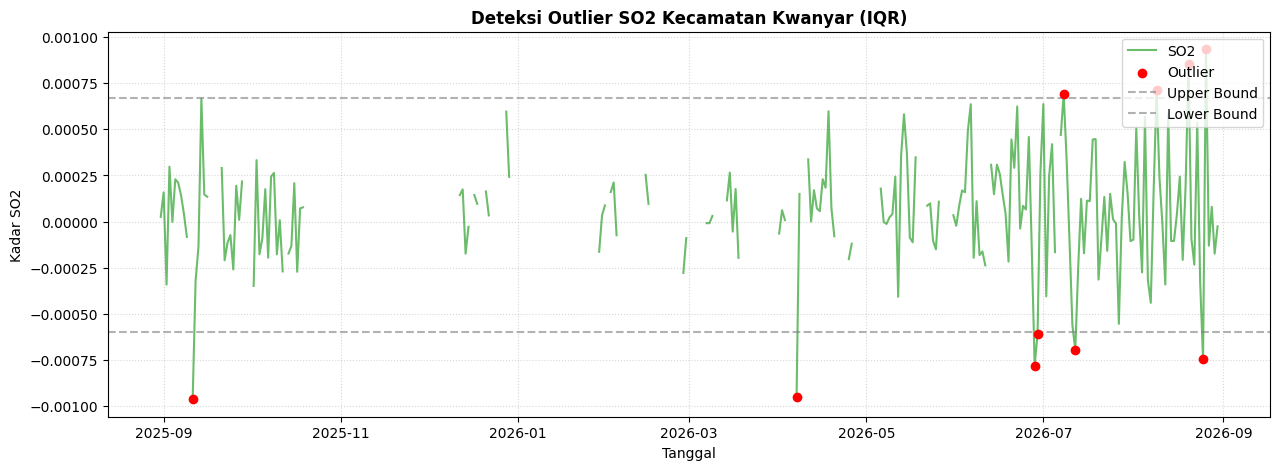

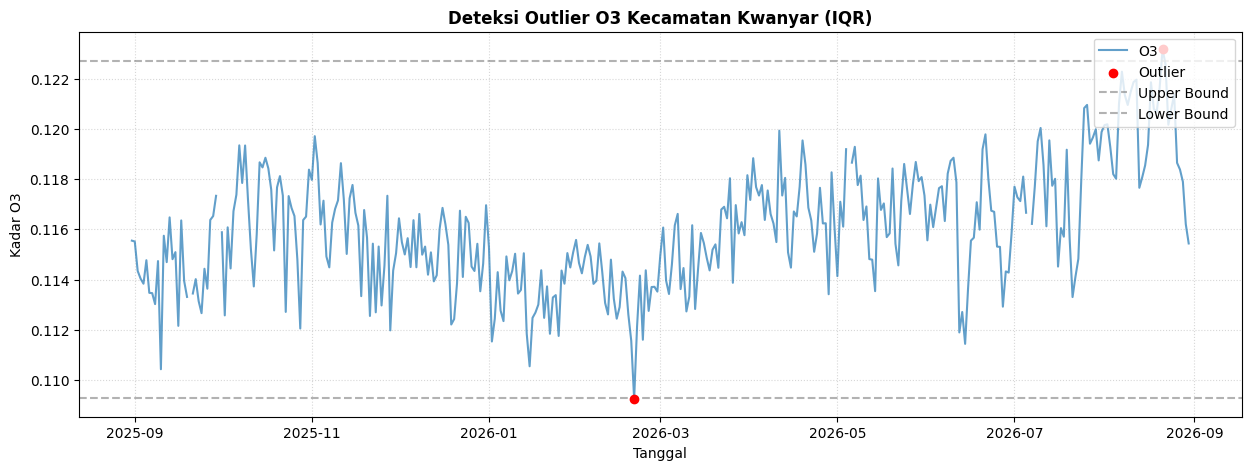

In [11]:
fitur_polutan = ['CO', 'NO2', 'SO2', 'O3']
warna_polutan = {'CO': 'tab:orange', 'NO2': 'tab:red', 'SO2': 'tab:green', 'O3': 'tab:blue'}

for kolom in fitur_polutan:
    if kolom in df.columns:
        Q1 = df[kolom].quantile(0.25)
        Q3 = df[kolom].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - (1.5 * IQR)
        upper_bound = Q3 + (1.5 * IQR)

        outliers_iqr = df[(df[kolom] < lower_bound) | (df[kolom] > upper_bound)]

        plt.figure(figsize=(15, 5))
        plt.plot(df['date'], df[kolom], label=kolom, color=warna_polutan[kolom], alpha=0.7)
        plt.scatter(outliers_iqr['date'], outliers_iqr[kolom], color='red', label='Outlier', zorder=5)

        plt.axhline(upper_bound, color='grey', linestyle='dashed', label='Upper Bound', alpha=0.6)
        plt.axhline(lower_bound, color='grey', linestyle='dashed', label='Lower Bound', alpha=0.6)

        plt.title(f"Deteksi Outlier {kolom} Kecamatan Kwanyar (IQR)", fontweight='bold')
        plt.xlabel("Tanggal")
        plt.ylabel(f"Kadar {kolom}")
        plt.legend(loc='upper right')
        plt.grid(True, linestyle=':', alpha=0.5)
        plt.show()